# 01 - Exploratory Data Analysis (EDA)

このノートブックは、灌漑予測コンペのデータ理解を行います。

## Contents
1. データ読み込みと基本情報
2. 欠損値分析
3. 統計量と分布
4. クラス分布分析
5. 特徴量相関
6. カテゴリ変数の分析
7. 外れ値検出
8. ドメイン知識に基づく発見

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import os
import warnings
warnings.filterwarnings('ignore')


# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Paths
TRAIN_PATH = 'data/train.csv'
TEST_PATH = 'data/test.csv'
ANALYSIS_DIR = Path('data/analysis')
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print('Imports successful!')

Current working directory: d:\program\Kaggle\Kaggle_Predicting_Irrigation_Need
Files in current directory: ['.git', '.gitignore', '01_EDA.ipynb', 'csiro-biomass-agentic-solution-main', 'data']
Imports successful!


## 1. データ読み込みと基本情報

In [2]:
# Load data
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('\nColumn names and types:')
print(train_df.dtypes)
print('\nFirst few rows:')
train_df.head()

Train shape: (630000, 21)
Test shape: (270000, 20)

Column names and types:
id                           int64
Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                   object
Crop_Growth_Stage           object
Season                      object
Irrigation_Type             object
Water_Source                object
Field_Area_hectare         float64
Mulching_Used               object
Previous_Irrigation_mm     float64
Region                      object
Irrigation_Need             object
dtype: object

First few rows:


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


## 2. 欠損値分析

In [3]:
# Missing value analysis
null_counts = train_df.isnull().sum()
null_pct = (null_counts / len(train_df)) * 100
null_analysis = pd.DataFrame({
    'Column': null_counts.index,
    'Null_Count': null_counts.values,
    'Null_Percentage': null_pct.values
}).sort_values('Null_Count', ascending=False)

print('Missing Value Analysis:')
print(null_analysis[null_analysis['Null_Count'] > 0])

# Save to analysis
null_analysis.to_dict('list')
with open(ANALYSIS_DIR / 'null_analysis.json', 'w') as f:
    json.dump(null_analysis.to_dict('list'), f, indent=2)

Missing Value Analysis:
Empty DataFrame
Columns: [Column, Null_Count, Null_Percentage]
Index: []


## 3. 統計量と分布

In [4]:
# Basic statistics for numerical columns
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print('Numerical columns:', numerical_cols)
print('\nBasic Statistics:')
stats = train_df[numerical_cols].describe().T
print(stats)

# Save statistics
stats_dict = train_df[numerical_cols].describe().to_dict()
with open(ANALYSIS_DIR / 'feature_stats.json', 'w') as f:
    json.dump(stats_dict, f, indent=2)

Numerical columns: ['id', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

Basic Statistics:
                            count           mean            std    min  \
id                       630000.0  314999.500000  181865.479132   0.00   
Soil_pH                  630000.0       6.482497       0.922504   4.80   
Soil_Moisture            630000.0      37.304482      16.377082   8.00   
Organic_Carbon           630000.0       0.922858       0.365808   0.30   
Electrical_Conductivity  630000.0       1.744605       0.952321   0.10   
Temperature_C            630000.0      26.998166       8.623621  12.00   
Humidity                 630000.0      61.563180      19.708152  25.00   
Rainfall_mm              630000.0    1462.207566     612.989738   0.38   
Sunlight_Hours           630000.0       7.513382       1.999322   4.00   
Wind_Speed_kmh

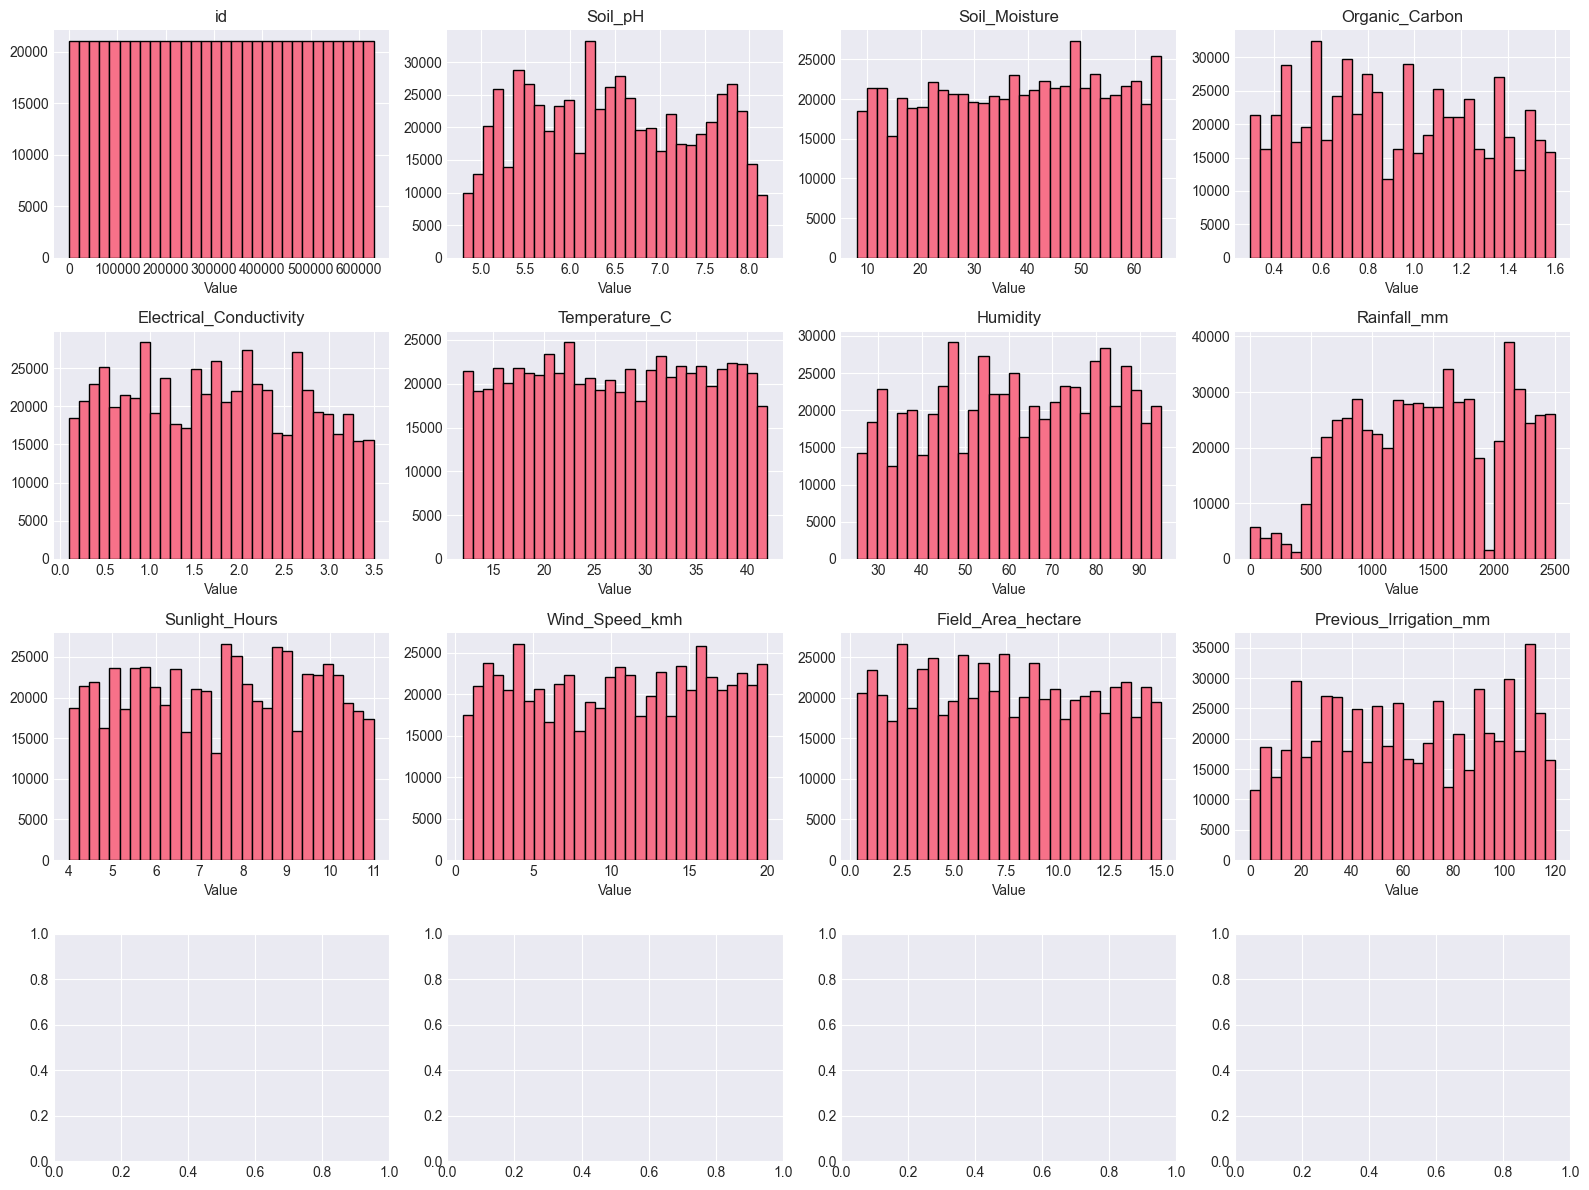

✓ Distribution plots saved


In [5]:
# Distribution plots
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        axes[idx].hist(train_df[col].dropna(), bins=30, edgecolor='black')
        axes[idx].set_title(col)
        axes[idx].set_xlabel('Value')

plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Distribution plots saved')

## 4. クラス分布分析 (ターゲット変数)

In [ ]:
# Target variable analysis
if 'Irrigation_Need' in train_df.columns:
    target_col = 'Irrigation_Need'
    
    # Class distribution
    class_dist = train_df[target_col].value_counts()
    class_pct = train_df[target_col].value_counts(normalize=True) * 100
    
    print(f'Target Variable: {target_col}')
    print(f'\nClass Distribution:')
    print(f'  Class 0 (No irrigation): {class_dist.get(0, 0)} ({class_pct.get(0, 0):.2f}%)')
    print(f'  Class 1 (Irrigation needed): {class_dist.get(1, 0)} ({class_pct.get(1, 0):.2f}%)')
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    class_dist.plot(kind='bar', ax=axes[0], edgecolor='black')
    axes[0].set_title('Class Distribution (Count)')
    axes[0].set_ylabel('Count')
    
    class_pct.plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
    axes[1].set_title('Class Distribution (Percentage)')
    
    plt.tight_layout()
    plt.savefig('target_distribution.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print('\n⚠️ Class Imbalance Ratio:', class_dist.max() / class_dist.min())

## 5. 特徴量相関分析

In [ ]:
# Correlation analysis
corr_matrix = train_df[numerical_cols].corr()

# Save correlation matrix
with open(ANALYSIS_DIR / 'correlation_matrix.json', 'w') as f:
    json.dump(corr_matrix.to_dict(), f, indent=2)

# Correlation with target
if 'Irrigation_Need' in train_df.columns and 'Irrigation_Need' in numerical_cols:
    target_corr = corr_matrix['Irrigation_Need'].sort_values(ascending=False)
    print('Correlation with Irrigation_Need:')
    print(target_corr)

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Correlation analysis complete')

## 6. カテゴリ変数の分析

In [ ]:
# Categorical columns analysis
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')

for col in categorical_cols:
    unique_count = train_df[col].nunique()
    most_common = train_df[col].value_counts().head(3)
    print(f'\n{col}:')
    print(f'  Unique values: {unique_count}')
    print(f'  Most common:')
    for val, count in most_common.items():
        print(f'    {val}: {count} ({count/len(train_df)*100:.1f}%)')

In [ ]:
# Categorical vs target visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols[:6]):
    crosstab = pd.crosstab(train_df[col], train_df.get('Irrigation_Need', 0))
    crosstab.plot(kind='bar', ax=axes[idx], edgecolor='black')
    axes[idx].set_title(f'{col} vs Irrigation_Need')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Categorical analysis complete')

## 7. 外れ値検出

In [ ]:
# Outlier detection using IQR
def detect_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[col] < lower_bound) | (data[col] > upper_bound)

print('Outlier Detection (IQR method):')
for col in numerical_cols:
    outliers = detect_outliers(train_df, col)
    outlier_count = outliers.sum()
    if outlier_count > 0:
        print(f'  {col}: {outlier_count} outliers ({outlier_count/len(train_df)*100:.2f}%)')

## 8. ドメイン知識に基づく発見

In [ ]:
# Domain insights
insights = {
    'total_samples': len(train_df),
    'total_features': len(train_df.columns),
    'numerical_features': len(numerical_cols),
    'categorical_features': len(categorical_cols),
    'target_distribution': train_df.get('Irrigation_Need', pd.Series()).value_counts().to_dict(),
    'missing_values': int(train_df.isnull().sum().sum()),
    'data_quality': 'High' if train_df.isnull().sum().sum() == 0 else 'Needs Attention'
}

print('\n=== EDA Summary ===')
for key, value in insights.items():
    print(f'{key}: {value}')

# Save insights
with open('eda_summary.json', 'w') as f:
    json.dump(insights, f, indent=2)

print('\n✓ EDA Analysis Complete!')